<a href="https://colab.research.google.com/github/Anudeepkonka/hospital-patient-analysis/blob/main/Hospital_patient_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("All libraries imported successfully!")

All libraries imported successfully!


In [136]:
df = pd.read_csv("/content/Hospital Patient .csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [137]:
df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [138]:
print("Dataset Shape:", df.shape)

Dataset Shape: (984, 15)


In [139]:
print(df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication ', 'Admission_Date', 'Discharge_Date', 'Patient_State', 'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction', 'Insurance_Claimed', 'Total_Cost']


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         984 non-null    int64 
 1   Age                984 non-null    int64 
 2   Gender             984 non-null    object
 3   Condition          984 non-null    object
 4   Medication         984 non-null    object
 5   Admission_Date     984 non-null    object
 6   Discharge_Date     984 non-null    object
 7   Patient_State      984 non-null    object
 8   Year_of_Admission  984 non-null    int64 
 9   Length_of_Stay     984 non-null    int64 
 10  Readmission        984 non-null    object
 11  Outcome            984 non-null    object
 12  Satisfaction       984 non-null    int64 
 13  Insurance_Claimed  984 non-null    object
 14  Total_Cost         984 non-null    int64 
dtypes: int64(6), object(9)
memory usage: 115.4+ KB


In [141]:
df.describe(include='all')

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
count,984.00,984.00,984,984,984,984,984,984,984.00,984.00,984,984,984.00,984,984.00
unique,NaN,NaN,2,15,15,709,723,30,NaN,NaN,2,2,NaN,2,NaN
top,NaN,NaN,Female,Fractured Leg,Cast and Physical Therapy,29-04-2023,20-05-2022,Kerala,NaN,NaN,No,Recovered,NaN,No,NaN
freq,NaN,NaN,524,67,67,4,4,120,NaN,NaN,720,591,NaN,633,NaN
mean,492.50,53.75,NaN,NaN,NaN,NaN,NaN,NaN,2023.46,37.66,NaN,NaN,3.60,NaN,8367.48
std,284.20,14.94,NaN,NaN,NaN,NaN,NaN,NaN,1.11,19.60,NaN,NaN,0.88,NaN,7761.99
min,1.00,25.00,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,1.00,NaN,NaN,2.00,NaN,100.00
25%,246.75,45.00,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,21.00,NaN,NaN,3.00,NaN,1000.00
50%,492.50,55.00,NaN,NaN,NaN,NaN,NaN,NaN,2023.00,38.00,NaN,NaN,4.00,NaN,6000.00
75%,738.25,65.00,NaN,NaN,NaN,NaN,NaN,NaN,2024.00,54.25,NaN,NaN,4.00,NaN,15000.00


In [142]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Values': missing_values.values,
    'Missing_Percentage': (missing_values.values / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by='Missing_Values',
    ascending=False
)

missing_summary

,Column,Missing_Values,Missing_Percentage
0,Patient_ID,0,0.00
1,Age,0,0.00
2,Gender,0,0.00
3,Condition,0,0.00
4,Medication,0,0.00
5,Admission_Date,0,0.00
6,Discharge_Date,0,0.00
7,Patient_State,0,0.00
8,Year_of_Admission,0,0.00
9,Length_of_Stay,0,0.00


In [143]:
duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 0


In [144]:
data_types = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str)
})

data_types

,Column,Data_Type
Patient_ID,Patient_ID,int64
Age,Age,int64
Gender,Gender,object
Condition,Condition,object
Medication,Medication,object
Admission_Date,Admission_Date,object
Discharge_Date,Discharge_Date,object
Patient_State,Patient_State,object
Year_of_Admission,Year_of_Admission,int64
Length_of_Stay,Length_of_Stay,int64


In [145]:
for column in df.columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(f"Unique Values: {df[column].nunique()}")

    if df[column].nunique() <= 20:
        print(df[column].value_counts(dropna=False))


Column: Patient_ID
Unique Values: 984

Column: Age
Unique Values: 22

Column: Gender
Unique Values: 2
Gender
Female    524
Male      460
Name: count, dtype: int64

Column: Condition
Unique Values: 15
Condition
Fractured Leg            67
Heart Attack             67
Fractured Arm            66
Hypertension             66
Appendicitis             66
Cancer                   66
Stroke                   66
Allergic Reaction        66
Diabetes                 65
Heart Disease            65
Respiratory Infection    65
Prostate Cancer          65
Childbirth               65
Kidney Stones            65
Osteoarthritis           64
Name: count, dtype: int64

Column: Medication 
Unique Values: 15
Medication 
Cast and Physical Therapy               67
Cardiac Catheterization                 67
X-Ray and Splint                        66
Medication and Counseling               66
Appendectomy                            66
Surgery and Chemotherapy                66
CT Scan and Medication            

In [146]:
quality_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isnull().sum().values,
    'Missing Percentage': (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    'Unique Values': df.nunique().values
})

quality_summary

,Column,Data Type,Missing Values,Missing Percentage,Unique Values
0,Patient_ID,int64,0,0.00,984
1,Age,int64,0,0.00,22
2,Gender,object,0,0.00,2
3,Condition,object,0,0.00,15
4,Medication,object,0,0.00,15
5,Admission_Date,object,0,0.00,709
6,Discharge_Date,object,0,0.00,723
7,Patient_State,object,0,0.00,30
8,Year_of_Admission,int64,0,0.00,4
9,Length_of_Stay,int64,0,0.00,76


In [147]:
print(df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication ', 'Admission_Date', 'Discharge_Date', 'Patient_State', 'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction', 'Insurance_Claimed', 'Total_Cost']


In [148]:
missing_summary

,Column,Missing_Values,Missing_Percentage
0,Patient_ID,0,0.00
1,Age,0,0.00
2,Gender,0,0.00
3,Condition,0,0.00
4,Medication,0,0.00
5,Admission_Date,0,0.00
6,Discharge_Date,0,0.00
7,Patient_State,0,0.00
8,Year_of_Admission,0,0.00
9,Length_of_Stay,0,0.00


In [149]:
hospital_df = df.copy()

print("Original Shape:", df.shape)
print("Working Dataset Shape:", hospital_df.shape)

Original Shape: (984, 15)
Working Dataset Shape: (984, 15)


In [150]:
hospital_df.columns = (
    hospital_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("-", "_")
)

print(hospital_df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication', 'Admission_Date', 'Discharge_Date', 'Patient_State', 'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction', 'Insurance_Claimed', 'Total_Cost']


In [151]:
before_duplicates = len(hospital_df)

hospital_df = hospital_df.drop_duplicates()

after_duplicates = len(hospital_df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 984
Rows after removing duplicates: 984
Duplicates removed: 0


In [152]:
missing_after_cleaning = hospital_df.isnull().sum()

missing_after_cleaning = missing_after_cleaning[
    missing_after_cleaning > 0
].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_after_cleaning)

Columns with missing values:
Series([], dtype: int64)


In [153]:
text_columns = hospital_df.select_dtypes(
    include=['object']
).columns

for column in text_columns:
    hospital_df[column] = hospital_df[column].astype(str).str.strip()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [154]:
hospital_df.replace(
    ['', 'NA', 'N/A', 'null', 'NULL', 'None', 'none'],
    np.nan,
    inplace=True
)

print("Common missing value formats converted to NaN.")

Common missing value formats converted to NaN.


In [155]:
print(
    hospital_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

Patient_ID           0
Age                  0
Gender               0
Condition            0
Medication           0
Admission_Date       0
Discharge_Date       0
Patient_State        0
Year_of_Admission    0
Length_of_Stay       0
Readmission          0
Outcome              0
Satisfaction         0
Insurance_Claimed    0
Total_Cost           0
dtype: int64


In [156]:
for column in hospital_df.columns:
    print(column)

Patient_ID
Age
Gender
Condition
Medication
Admission_Date
Discharge_Date
Patient_State
Year_of_Admission
Length_of_Stay
Readmission
Outcome
Satisfaction
Insurance_Claimed
Total_Cost


In [157]:
hospital_df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [158]:
print(hospital_df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication', 'Admission_Date', 'Discharge_Date', 'Patient_State', 'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction', 'Insurance_Claimed', 'Total_Cost']


In [159]:
hospital_df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [160]:
print("CLEANED COLUMN NAMES:")
for i, column in enumerate(hospital_df.columns, start=1):
    print(f"{i}. {column}")

CLEANED COLUMN NAMES:
1. Patient_ID
2. Age
3. Gender
4. Condition
5. Medication
6. Admission_Date
7. Discharge_Date
8. Patient_State
9. Year_of_Admission
10. Length_of_Stay
11. Readmission
12. Outcome
13. Satisfaction
14. Insurance_Claimed
15. Total_Cost


In [161]:
date_keywords = ['date', 'admission', 'discharge']

possible_date_columns = [
    column for column in hospital_df.columns
    if any(keyword in column.lower() for keyword in date_keywords)
]

print("Possible Date Columns:")
print(possible_date_columns)

Possible Date Columns:
['Admission_Date', 'Discharge_Date', 'Year_of_Admission', 'Readmission']


In [162]:
for column in possible_date_columns:
    hospital_df[column] = pd.to_datetime(
        hospital_df[column],
        errors='coerce'
    )

print("Date columns converted successfully!")

Date columns converted successfully!


/tmp/ipykernel_829/180721284.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hospital_df[column] = pd.to_datetime(


In [163]:
print(hospital_df.dtypes)

Patient_ID                    int64
Age                           int64
Gender                       object
Condition                    object
Medication                   object
Admission_Date       datetime64[ns]
Discharge_Date       datetime64[ns]
Patient_State                object
Year_of_Admission    datetime64[ns]
Length_of_Stay                int64
Readmission          datetime64[ns]
Outcome                      object
Satisfaction                  int64
Insurance_Claimed            object
Total_Cost                    int64
dtype: object


In [164]:
for column in possible_date_columns:
    print(
        f"{column}: "
        f"{hospital_df[column].isnull().sum()} missing or invalid dates"
    )

Admission_Date: 604 missing or invalid dates
Discharge_Date: 599 missing or invalid dates
Year_of_Admission: 0 missing or invalid dates
Readmission: 984 missing or invalid dates


In [165]:
admission_columns = [
    col for col in hospital_df.columns
    if 'admission' in col.lower() and 'date' in col.lower()
]

discharge_columns = [
    col for col in hospital_df.columns
    if 'discharge' in col.lower() and 'date' in col.lower()
]

print("Admission Date Columns:", admission_columns)
print("Discharge Date Columns:", discharge_columns)

Admission Date Columns: ['Admission_Date']
Discharge Date Columns: ['Discharge_Date']


In [166]:
admission_col = admission_columns[0]
discharge_col = discharge_columns[0]

hospital_df['Length_of_Stay'] = (
    hospital_df[discharge_col] - hospital_df[admission_col]
).dt.days

print("Length_of_Stay created successfully!")

Length_of_Stay created successfully!


In [167]:
print(
    "Negative Length of Stay Records:",
    (hospital_df['Length_of_Stay'] < 0).sum()
)

print(
    "Zero Length of Stay Records:",
    (hospital_df['Length_of_Stay'] == 0).sum()
)

hospital_df['Length_of_Stay'].describe()

Negative Length of Stay Records: 49
Zero Length of Stay Records: 0


,Length_of_Stay
count,137.00
mean,58.38
std,175.45
min,-303.00
25%,-30.00
50%,62.00
75%,153.00
max,629.00


In [168]:
hospital_df.loc[
    hospital_df['Length_of_Stay'] < 0,
    'Length_of_Stay'
] = np.nan

In [169]:
age_columns = [
    col for col in hospital_df.columns
    if 'age' in col.lower()
]

print("Possible Age Columns:", age_columns)

Possible Age Columns: ['Age']


In [170]:
age_col = age_columns[0]

hospital_df['Age_Group'] = pd.cut(
    hospital_df[age_col],
    bins=[0, 18, 30, 45, 60, 75, 120],
    labels=[
        '0-18',
        '19-30',
        '31-45',
        '46-60',
        '61-75',
        '76+'
    ],
    include_lowest=True
)

hospital_df['Age_Group'].value_counts()

,count
Age_Group,
46-60,359
61-75,262
31-45,198
19-30,99
76+,66
0-18,0


In [171]:
hospital_df['Stay_Category'] = pd.cut(
    hospital_df['Length_of_Stay'],
    bins=[-1, 1, 3, 7, np.inf],
    labels=[
        'Same Day / 1 Day',
        '2-3 Days',
        '4-7 Days',
        '8+ Days'
    ]
)

hospital_df['Stay_Category'].value_counts()

,count
Stay_Category,
8+ Days,78
Same Day / 1 Day,5
2-3 Days,5
4-7 Days,0


In [172]:
print("Final Dataset Shape:", hospital_df.shape)

print("\nNew Columns Added:")
print([
    'Length_of_Stay',
    'Age_Group',
    'Stay_Category'
])

Final Dataset Shape: (984, 17)

New Columns Added:
['Length_of_Stay', 'Age_Group', 'Stay_Category']


In [173]:
hospital_df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost,Age_Group,Stay_Category
0,1,45,Female,Heart Disease,Angioplasty,2024-07-02,2024-12-02,Kerala,1970-01-01 00:00:00.000002024,153.00,NaT,Recovered,4,Yes,15000,31-45,8+ Days
1,2,60,Male,Diabetes,Insulin Therapy,2023-11-03,NaT,Goa,1970-01-01 00:00:00.000002023,NaN,NaT,Stable,3,No,2000,46-60,NaN
2,3,32,Female,Fractured Arm,X-Ray and Splint,2025-02-01,2025-03-01,Maharastra,1970-01-01 00:00:00.000002025,28.00,NaT,Recovered,5,Yes,500,31-45,8+ Days
3,4,75,Male,Stroke,CT Scan and Medication,NaT,2024-06-01,Manipur,1970-01-01 00:00:00.000002023,NaN,NaT,Stable,2,No,10000,61-75,NaN
4,5,50,Female,Cancer,Surgery and Chemotherapy,2022-10-05,NaT,Mizoram,1970-01-01 00:00:00.000002022,NaN,NaT,Recovered,4,No,25000,46-60,NaN


In [174]:
keywords = [
    'cost',
    'charge',
    'bill',
    'readmission',
    'department',
    'diagnosis',
    'condition',
    'satisfaction',
    'gender',
    'insurance',
    'admission'
]

for keyword in keywords:
    matching_columns = [
        col for col in hospital_df.columns
        if keyword.lower() in col.lower()
    ]

    print(f"{keyword.upper()}: {matching_columns}")

COST: ['Total_Cost']
CHARGE: ['Discharge_Date']
BILL: []
READMISSION: ['Readmission']
DEPARTMENT: []
DIAGNOSIS: []
CONDITION: ['Condition']
SATISFACTION: ['Satisfaction']
GENDER: ['Gender']
INSURANCE: ['Insurance_Claimed']
ADMISSION: ['Admission_Date', 'Year_of_Admission', 'Readmission']


In [175]:
hospital_df['Admission_Year'] = hospital_df[admission_col].dt.year

hospital_df['Admission_Month'] = hospital_df[admission_col].dt.month

hospital_df['Admission_Month_Name'] = hospital_df[
    admission_col
].dt.month_name()

hospital_df['Admission_Quarter'] = (
    hospital_df[admission_col]
    .dt.to_period('Q')
    .astype(str)
)

hospital_df['Admission_Day_Name'] = hospital_df[
    admission_col
].dt.day_name()

print("Admission time features created successfully!")

hospital_df[
    [
        admission_col,
        'Admission_Year',
        'Admission_Month',
        'Admission_Month_Name',
        'Admission_Quarter',
        'Admission_Day_Name'
    ]
].head()

Admission time features created successfully!


,Admission_Date,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Day_Name
0,2024-07-02,2024.00,7.00,July,2024Q3,Tuesday
1,2023-11-03,2023.00,11.00,November,2023Q4,Friday
2,2025-02-01,2025.00,2.00,February,2025Q1,Saturday
3,NaT,NaN,NaN,NaN,NaT,NaN
4,2022-10-05,2022.00,10.00,October,2022Q4,Wednesday


In [176]:
cost_columns = [
    col for col in hospital_df.columns
    if any(
        keyword in col.lower()
        for keyword in ['cost', 'charge', 'bill', 'expense']
    )
]

print("Possible Cost Columns:", cost_columns)

Possible Cost Columns: ['Discharge_Date', 'Total_Cost']


In [177]:
cost_col = cost_columns[0]

hospital_df[cost_col] = pd.to_numeric(
    hospital_df[cost_col],
    errors='coerce'
)

print("Cost column selected:", cost_col)

hospital_df[cost_col].describe()

Cost column selected: Discharge_Date


,Discharge_Date
count,984.00
mean,-4947969311052856320.00
std,5335618772487800832.00
min,-9223372036854775808.00
25%,-9223372036854775808.00
50%,-9223372036854775808.00
75%,1688256000000000000.00
max,1793577600000000000.00


In [178]:
print("Selected Cost Column:", cost_col)
print(hospital_df[cost_col].describe())
print("Unique Cost Values:", hospital_df[cost_col].nunique())

Selected Cost Column: Discharge_Date
count                    984.00
mean    -4947969311052856320.00
std      5335618772487800832.00
min     -9223372036854775808.00
25%     -9223372036854775808.00
50%     -9223372036854775808.00
75%      1688256000000000000.00
max      1793577600000000000.00
Name: Discharge_Date, dtype: float64
Unique Cost Values: 287


In [179]:
# Remove missing values temporarily and calculate quartile cut points
cost_values = hospital_df[cost_col].dropna()

# Calculate unique quartile boundaries
bins = np.unique(
    cost_values.quantile([0, 0.25, 0.50, 0.75, 1.0]).values
)

print("Cost Bin Boundaries:", bins)
print("Number of Bins:", len(bins) - 1)

Cost Bin Boundaries: [-9.22337204e+18  1.68825600e+18  1.79357760e+18]
Number of Bins: 2


In [180]:
# Create labels based on the actual number of bins
all_labels = [
    'Low Cost',
    'Medium Cost',
    'High Cost',
    'Very High Cost'
]

labels = all_labels[:len(bins) - 1]

hospital_df['Cost_Category'] = pd.cut(
    hospital_df[cost_col],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Cost categories created successfully!")
print(hospital_df['Cost_Category'].value_counts(dropna=False))

Cost categories created successfully!
Cost_Category
Low Cost       739
Medium Cost    245
Name: count, dtype: int64


In [181]:
readmission_columns = [
    col for col in hospital_df.columns
    if 'readmission' in col.lower()
]

print("Possible Readmission Columns:", readmission_columns)

Possible Readmission Columns: ['Readmission']


In [182]:
readmission_col = readmission_columns[0]

print(
    hospital_df[readmission_col]
    .value_counts(dropna=False)
)

Readmission
NaT    984
Name: count, dtype: int64


In [183]:
hospital_df['Readmission_Flag'] = (
    hospital_df[readmission_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(['yes', 'y', 'true', '1'])
    .astype(int)
)

print(
    hospital_df['Readmission_Flag']
    .value_counts()
)

Readmission_Flag
0    984
Name: count, dtype: int64


In [184]:
id_columns = [
    col for col in hospital_df.columns
    if 'patient' in col.lower() and 'id' in col.lower()
]

print("Possible Patient ID Columns:", id_columns)

Possible Patient ID Columns: ['Patient_ID']


In [185]:
patient_id_col = id_columns[0]

print("Patient ID Column:", patient_id_col)
print(
    "Unique Patients:",
    hospital_df[patient_id_col].nunique()
)

Patient ID Column: Patient_ID
Unique Patients: 984


In [186]:
print("=" * 60)
print("HOSPITAL DATASET - FINAL OVERVIEW")
print("=" * 60)

print("\nDataset Shape:")
print(hospital_df.shape)

print("\nMissing Values:")
print(
    hospital_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nData Types:")
print(hospital_df.dtypes)

print("\nFirst 5 Records:")
display(hospital_df.head())

HOSPITAL DATASET - FINAL OVERVIEW

Dataset Shape:
(984, 24)

Missing Values:
Readmission             984
Length_of_Stay          896
Stay_Category           896
Admission_Date          604
Admission_Year          604
Admission_Day_Name      604
Admission_Month         604
Admission_Month_Name    604
Patient_State             0
Discharge_Date            0
Medication                0
Condition                 0
Age                       0
Gender                    0
Patient_ID                0
Year_of_Admission         0
Age_Group                 0
Total_Cost                0
Insurance_Claimed         0
Satisfaction              0
Outcome                   0
Admission_Quarter         0
Cost_Category             0
Readmission_Flag          0
dtype: int64

Data Types:
Patient_ID                       int64
Age                              int64
Gender                          object
Condition                       object
Medication                      object
Admission_Date          dateti

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost,Age_Group,Stay_Category,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Day_Name,Cost_Category,Readmission_Flag
0,1,45,Female,Heart Disease,Angioplasty,2024-07-02,1733097600000000000,Kerala,1970-01-01 00:00:00.000002024,153.00,NaT,Recovered,4,Yes,15000,31-45,8+ Days,2024.00,7.00,July,2024Q3,Tuesday,Medium Cost,0
1,2,60,Male,Diabetes,Insulin Therapy,2023-11-03,-9223372036854775808,Goa,1970-01-01 00:00:00.000002023,NaN,NaT,Stable,3,No,2000,46-60,NaN,2023.00,11.00,November,2023Q4,Friday,Low Cost,0
2,3,32,Female,Fractured Arm,X-Ray and Splint,2025-02-01,1740787200000000000,Maharastra,1970-01-01 00:00:00.000002025,28.00,NaT,Recovered,5,Yes,500,31-45,8+ Days,2025.00,2.00,February,2025Q1,Saturday,Medium Cost,0
3,4,75,Male,Stroke,CT Scan and Medication,NaT,1717200000000000000,Manipur,1970-01-01 00:00:00.000002023,NaN,NaT,Stable,2,No,10000,61-75,NaN,NaN,NaN,NaN,NaT,NaN,Medium Cost,0
4,5,50,Female,Cancer,Surgery and Chemotherapy,2022-10-05,-9223372036854775808,Mizoram,1970-01-01 00:00:00.000002022,NaN,NaT,Recovered,4,No,25000,46-60,NaN,2022.00,10.00,October,2022Q4,Wednesday,Low Cost,0


In [187]:
print("=" * 60)
print("HOSPITAL KEY PERFORMANCE INDICATORS")
print("=" * 60)

total_records = len(hospital_df)

total_patients = hospital_df[patient_id_col].nunique()

total_admissions = len(hospital_df)

average_stay = hospital_df['Length_of_Stay'].mean()

average_cost = hospital_df[cost_col].mean()

total_cost = hospital_df[cost_col].sum()

readmission_rate = (
    hospital_df['Readmission_Flag'].mean() * 100
)

print(f"Total Records: {total_records:,}")
print(f"Total Unique Patients: {total_patients:,}")
print(f"Total Admissions: {total_admissions:,}")
print(f"Average Length of Stay: {average_stay:.2f} Days")
print(f"Average Treatment Cost: {average_cost:,.2f}")
print(f"Total Treatment Cost: {total_cost:,.2f}")
print(f"Readmission Rate: {readmission_rate:.2f}%")

HOSPITAL KEY PERFORMANCE INDICATORS
Total Records: 984
Total Unique Patients: 984
Total Admissions: 984
Average Length of Stay: 154.91 Days
Average Treatment Cost: -4,947,969,311,052,856,320.00
Total Treatment Cost: 1,138,633,383,310,917,632.00
Readmission Rate: 0.00%


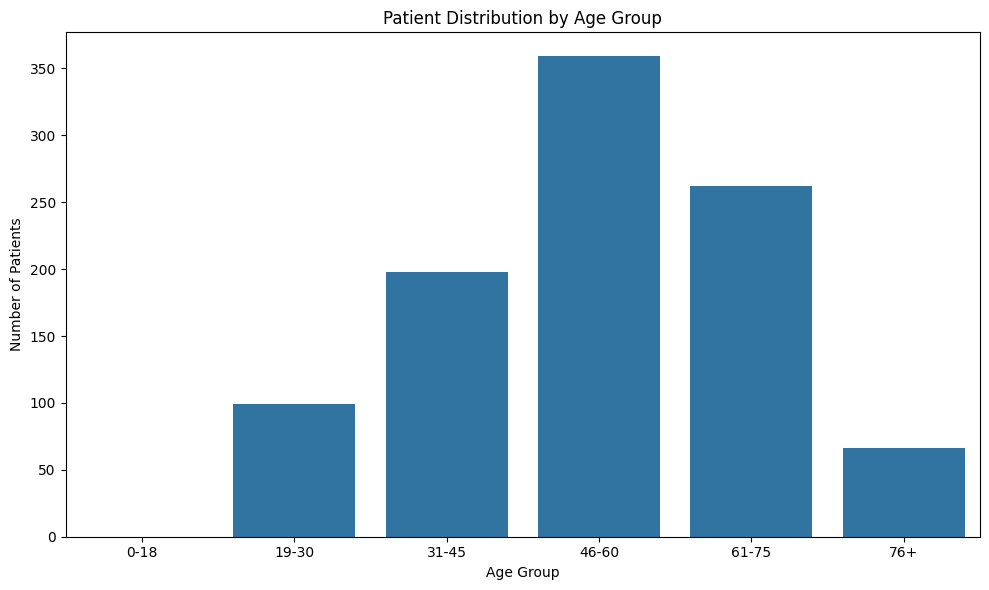

In [188]:
age_group_counts = (
    hospital_df['Age_Group']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [189]:
gender_columns = [
    col for col in hospital_df.columns
    if 'gender' in col.lower()
]

print("Possible Gender Columns:", gender_columns)

Possible Gender Columns: ['Gender']


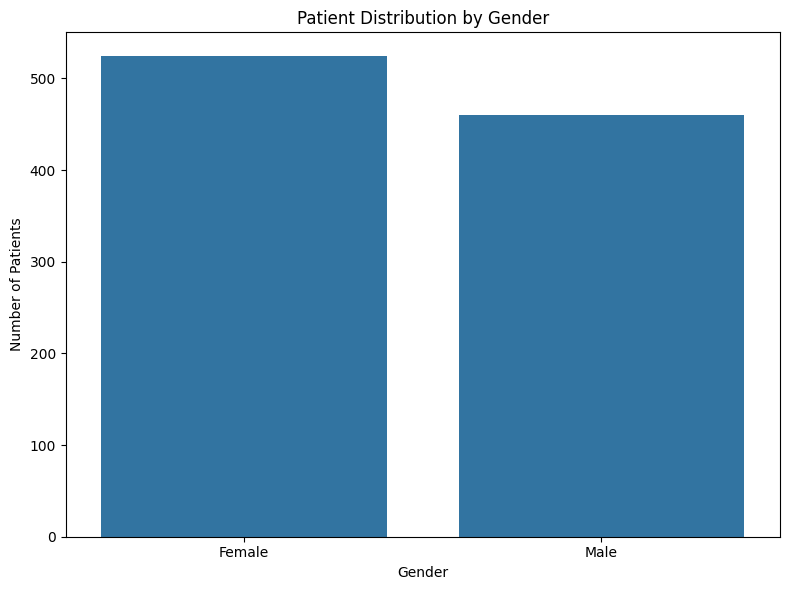

In [190]:
gender_col = gender_columns[0]

gender_counts = hospital_df[gender_col].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [191]:
yearly_admissions = (
    hospital_df
    .groupby('Admission_Year')
    .size()
    .reset_index(name='Admissions')
)

yearly_admissions

,Admission_Year,Admissions
0,2022.00,105
1,2023.00,93
2,2024.00,88
3,2025.00,94


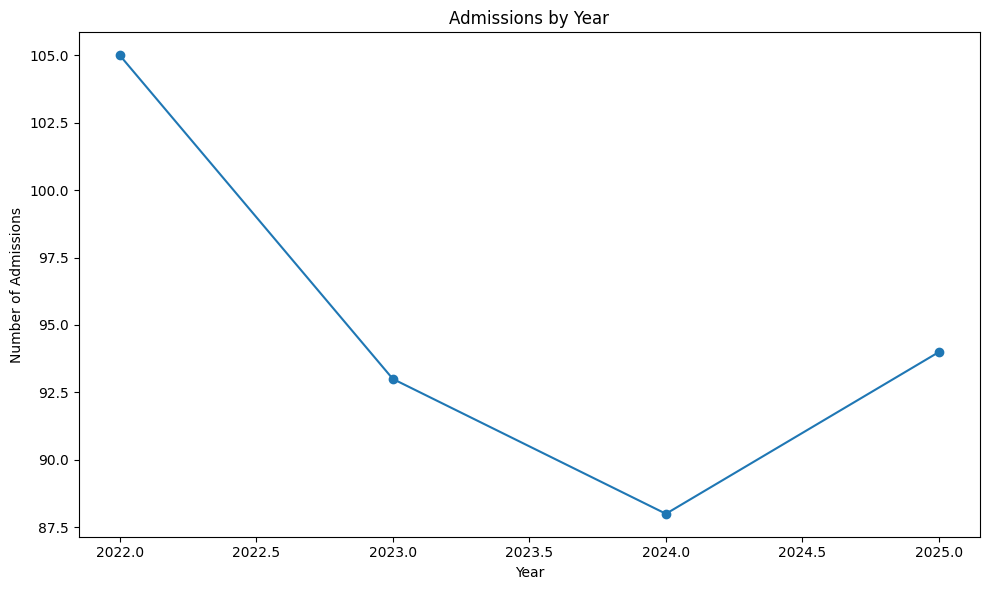

In [192]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_admissions['Admission_Year'],
    yearly_admissions['Admissions'],
    marker='o'
)

plt.title("Admissions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

In [193]:
monthly_admissions = (
    hospital_df
    .groupby('Admission_Month')
    .size()
    .reset_index(name='Admissions')
)

monthly_admissions

,Admission_Month,Admissions
0,1.00,35
1,2.00,29
2,3.00,34
3,4.00,26
4,5.00,35
5,6.00,32
6,7.00,31
7,8.00,32
8,9.00,38
9,10.00,31


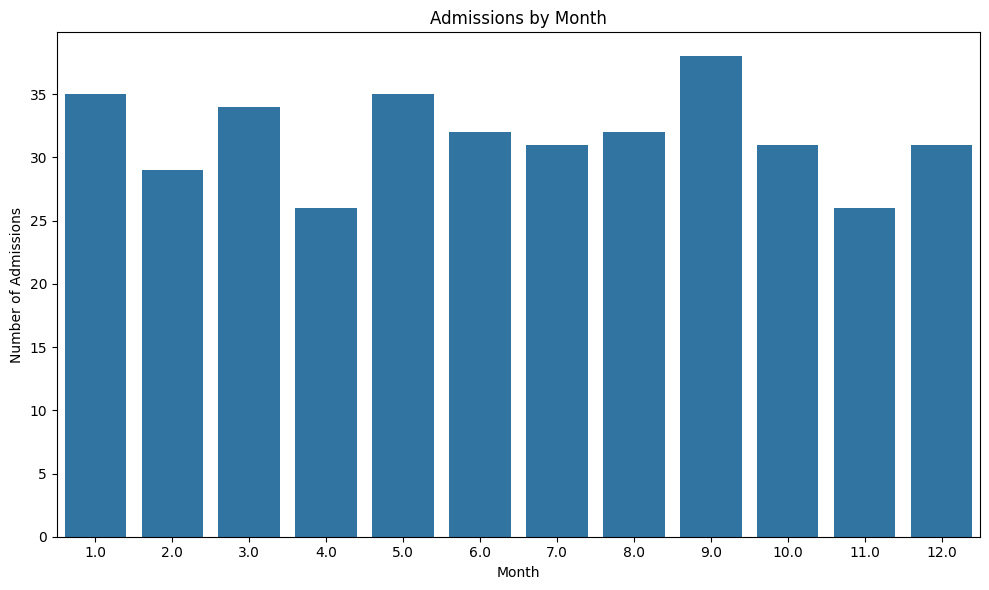

In [194]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_admissions,
    x='Admission_Month',
    y='Admissions'
)

plt.title("Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

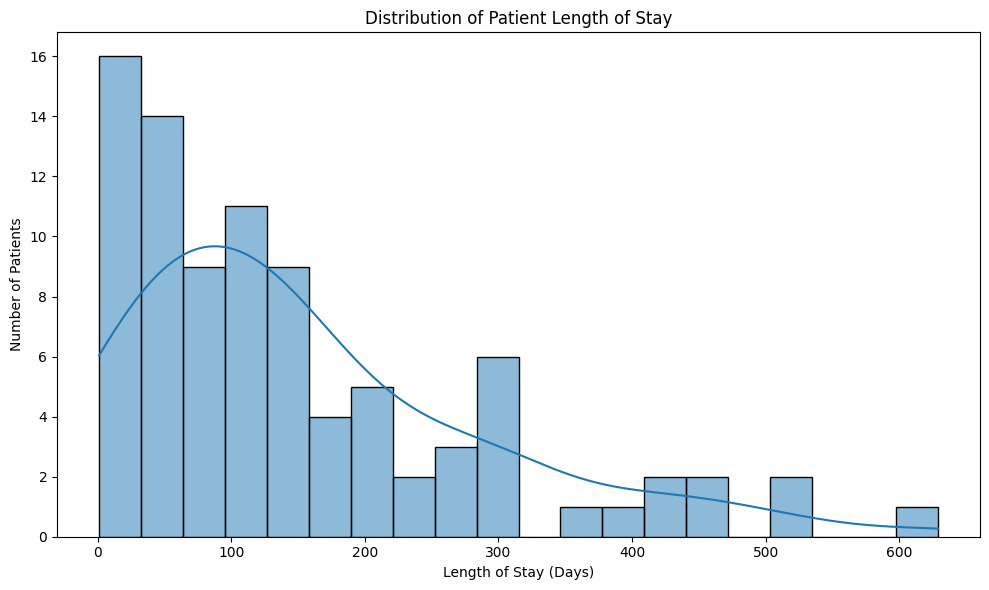

In [195]:
plt.figure(figsize=(10, 6))

sns.histplot(
    hospital_df['Length_of_Stay'].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Patient Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

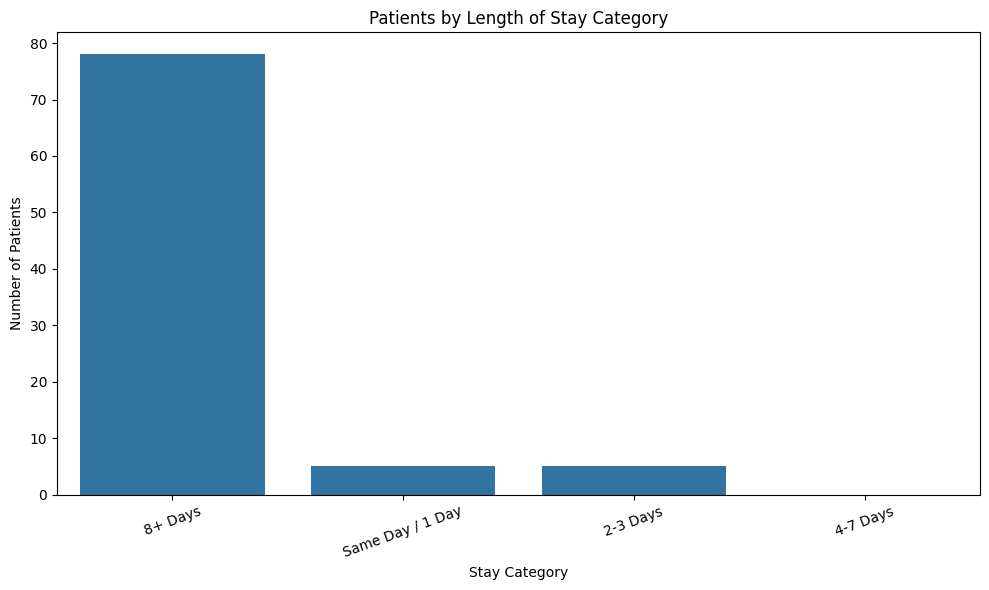

In [196]:
stay_counts = hospital_df['Stay_Category'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=stay_counts.index.astype(str),
    y=stay_counts.values
)

plt.title("Patients by Length of Stay Category")
plt.xlabel("Stay Category")
plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

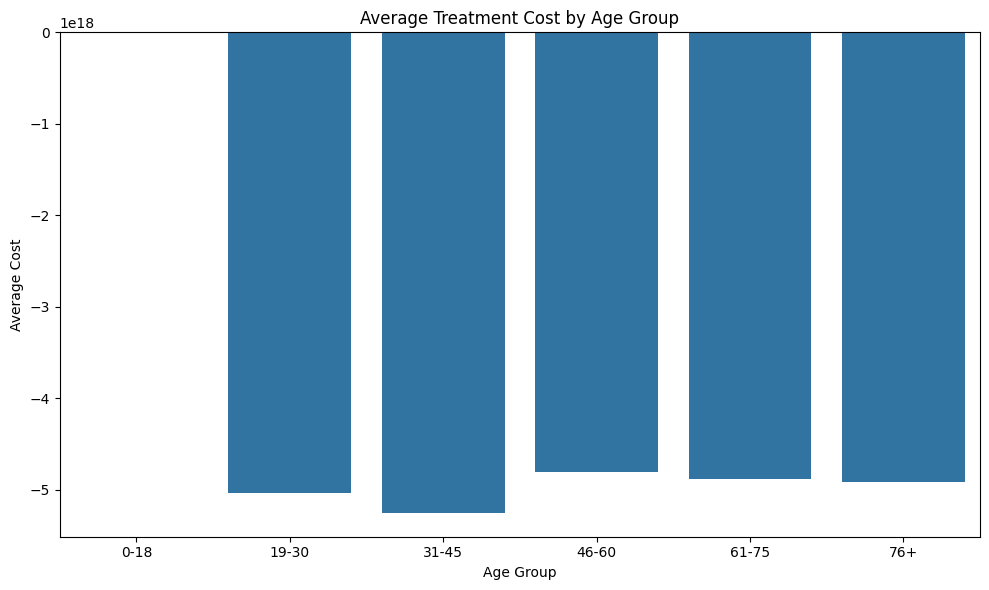

In [197]:
cost_by_age = (
    hospital_df
    .groupby('Age_Group', observed=False)[cost_col]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cost_by_age,
    x='Age_Group',
    y=cost_col
)

plt.title("Average Treatment Cost by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Cost")

plt.tight_layout()
plt.show()

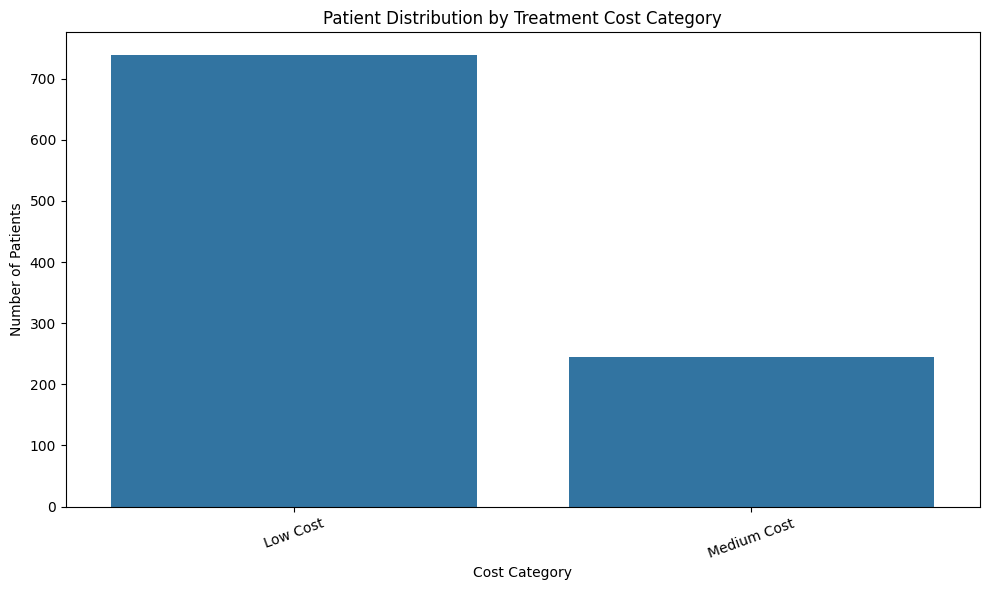

In [198]:
cost_category_counts = (
    hospital_df['Cost_Category']
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=cost_category_counts.index.astype(str),
    y=cost_category_counts.values
)

plt.title("Patient Distribution by Treatment Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

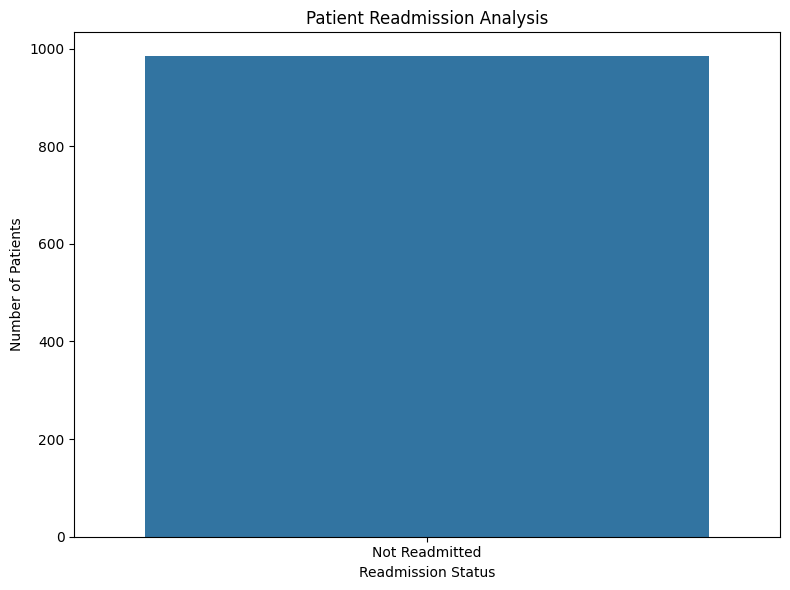

In [199]:
readmission_counts = (
    hospital_df['Readmission_Flag']
    .value_counts()
    .reset_index()
)

readmission_counts.columns = [
    'Readmission_Flag',
    'Patient_Count'
]

readmission_counts['Readmission_Status'] = (
    readmission_counts['Readmission_Flag']
    .map({
        1: 'Readmitted',
        0: 'Not Readmitted'
    })
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=readmission_counts,
    x='Readmission_Status',
    y='Patient_Count'
)

plt.title("Patient Readmission Analysis")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [200]:
readmission_by_age = (
    hospital_df
    .groupby('Age_Group', observed=False)['Readmission_Flag']
    .mean()
    .mul(100)
    .reset_index(name='Readmission_Rate')
)

readmission_by_age

,Age_Group,Readmission_Rate
0,0-18,NaN
1,19-30,0.00
2,31-45,0.00
3,46-60,0.00
4,61-75,0.00
5,76+,0.00


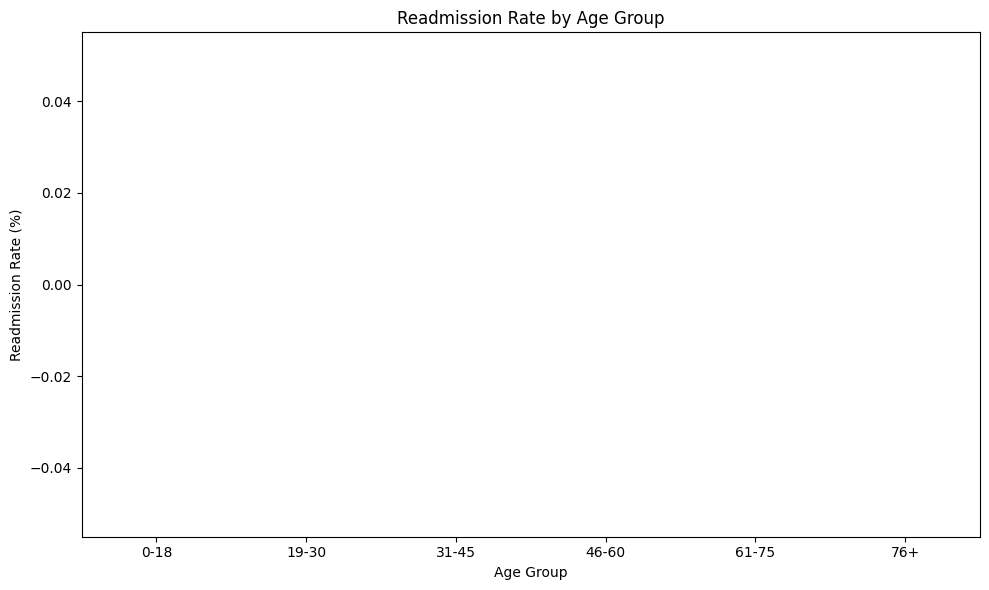

In [201]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=readmission_by_age,
    x='Age_Group',
    y='Readmission_Rate'
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

AVAILABLE COLUMNS FOR ANALYSIS
['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication', 'Admission_Date', 'Discharge_Date', 'Patient_State', 'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction', 'Insurance_Claimed', 'Total_Cost', 'Age_Group', 'Stay_Category', 'Admission_Year', 'Admission_Month', 'Admission_Month_Name', 'Admission_Quarter', 'Admission_Day_Name', 'Cost_Category', 'Readmission_Flag']

Possible Hospital Columns:
[]

No Hospital column found in this dataset.
We will use Medical Condition or another available category instead.

Possible Alternative Columns:
['Condition']

Selected Alternative Column: Condition

Analysis Results:


,Condition,Admissions,Average_Stay,Average_Cost,Readmission_Rate
6,Fractured Leg,67,152.00,-4329629954680995840.00,0.00
7,Heart Attack,67,98.60,-5147087378326874112.00,0.00
1,Appendicitis,66,115.33,-5082132616834027520.00,0.00
2,Cancer,66,113.00,-5252378568907584512.00,0.00
5,Fractured Arm,66,61.00,-6248505044985291776.00,0.00
9,Hypertension,66,173.50,-5088486944106755072.00,0.00
0,Allergic Reaction,66,218.00,-4753302094505095168.00,0.00
14,Stroke,66,145.60,-4584865306067901440.00,0.00
4,Diabetes,65,102.17,-4855246212882096128.00,0.00
3,Childbirth,65,100.38,-5691312369563233280.00,0.00


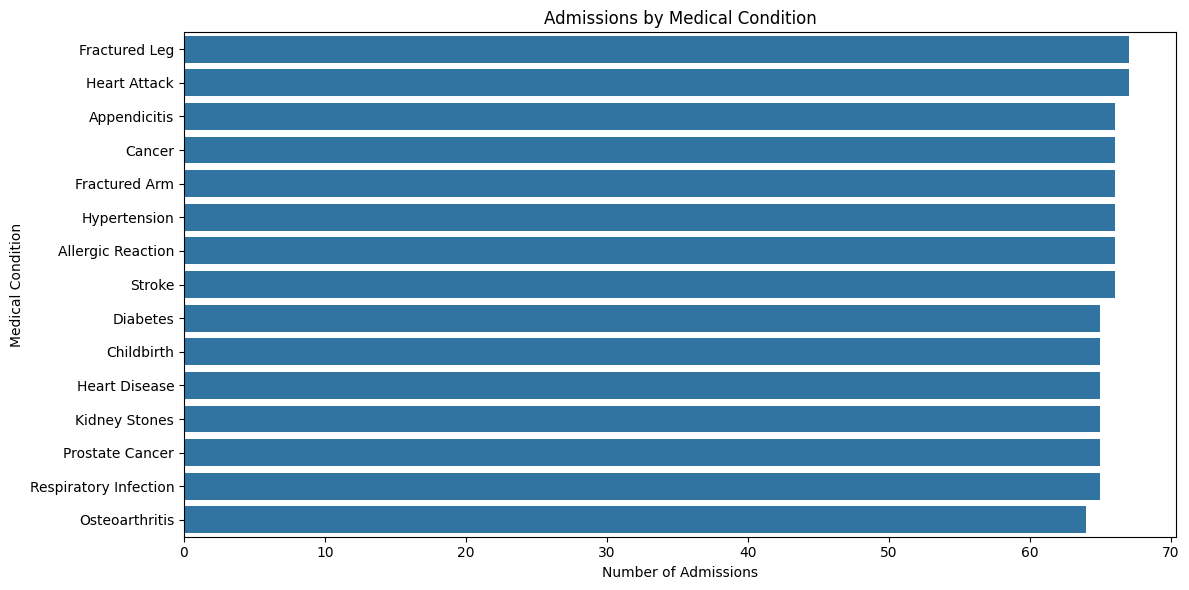

In [202]:
# ==========================================
# HOSPITAL / ALTERNATIVE CATEGORY ANALYSIS
# ==========================================

print("=" * 60)
print("AVAILABLE COLUMNS FOR ANALYSIS")
print("=" * 60)

print(hospital_df.columns.tolist())


# Find possible hospital columns
hospital_columns = [
    col for col in hospital_df.columns
    if 'hospital' in col.lower()
]

print("\nPossible Hospital Columns:")
print(hospital_columns)


# Check whether a hospital column exists
if len(hospital_columns) > 0:

    hospital_col = hospital_columns[0]

    print("\nSelected Hospital Column:", hospital_col)

    # Create hospital-wise analysis
    hospital_analysis = (
        hospital_df
        .groupby(hospital_col)
        .agg(
            Admissions=(patient_id_col, 'count'),
            Average_Stay=('Length_of_Stay', 'mean'),
            Average_Cost=(cost_col, 'mean'),
            Readmission_Rate=(
                'Readmission_Flag',
                lambda x: x.mean() * 100
            )
        )
        .reset_index()
        .sort_values('Admissions', ascending=False)
    )

    print("\nTop 10 Hospital Analysis:")
    display(hospital_analysis.head(10))


    # Select Top 10 Hospitals
    top_hospitals = hospital_analysis.head(10)

    # Create chart
    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=top_hospitals,
        x='Admissions',
        y=hospital_col
    )

    plt.title("Top 10 Hospitals by Number of Admissions")
    plt.xlabel("Number of Admissions")
    plt.ylabel("Hospital")

    plt.tight_layout()
    plt.show()


else:

    print("\nNo Hospital column found in this dataset.")
    print("We will use Medical Condition or another available category instead.")

    # Find condition / diagnosis / medical columns
    alternative_columns = [
        col for col in hospital_df.columns
        if any(keyword in col.lower() for keyword in [
            'medical_condition',
            'condition',
            'diagnosis',
            'medical'
        ])
    ]

    print("\nPossible Alternative Columns:")
    print(alternative_columns)

    if len(alternative_columns) > 0:

        alternative_col = alternative_columns[0]

        print("\nSelected Alternative Column:", alternative_col)

        alternative_analysis = (
            hospital_df
            .groupby(alternative_col)
            .agg(
                Admissions=(patient_id_col, 'count'),
                Average_Stay=('Length_of_Stay', 'mean'),
                Average_Cost=(cost_col, 'mean'),
                Readmission_Rate=(
                    'Readmission_Flag',
                    lambda x: x.mean() * 100
                )
            )
            .reset_index()
            .sort_values('Admissions', ascending=False)
        )

        print("\nAnalysis Results:")
        display(alternative_analysis)

        plt.figure(figsize=(12, 6))

        sns.barplot(
            data=alternative_analysis,
            x='Admissions',
            y=alternative_col
        )

        plt.title("Admissions by Medical Condition")
        plt.xlabel("Number of Admissions")
        plt.ylabel("Medical Condition")

        plt.tight_layout()
        plt.show()

    else:
        print("No suitable Hospital, Condition, or Diagnosis column was found.")
        print("Please check the column names printed above.")

In [203]:
# ==========================================
# STEP 29 - FINAL DATA VALIDATION
# ==========================================

print("=" * 60)
print("FINAL DATA VALIDATION")
print("=" * 60)

# Dataset shape
print("\n1. Final Dataset Shape:")
print(hospital_df.shape)

# Duplicate records
print("\n2. Duplicate Rows:")
print(hospital_df.duplicated().sum())

# Missing values
print("\n3. Missing Values:")
missing_final = hospital_df.isnull().sum()

missing_final_summary = missing_final[
    missing_final > 0
].sort_values(ascending=False)

if len(missing_final_summary) == 0:
    print("No missing values found!")
else:
    print(missing_final_summary)

# Negative length of stay
print("\n4. Negative Length of Stay:")
print((hospital_df['Length_of_Stay'] < 0).sum())

# Dataset columns
print("\n5. Total Columns:")
print(len(hospital_df.columns))

print("\n6. Final Column Names:")
for i, col in enumerate(hospital_df.columns, start=1):
    print(f"{i}. {col}")

print("\nData validation completed successfully!")

FINAL DATA VALIDATION

1. Final Dataset Shape:
(984, 24)

2. Duplicate Rows:
0

3. Missing Values:
Readmission             984
Length_of_Stay          896
Stay_Category           896
Admission_Date          604
Admission_Year          604
Admission_Month         604
Admission_Month_Name    604
Admission_Day_Name      604
dtype: int64

4. Negative Length of Stay:
0

5. Total Columns:
24

6. Final Column Names:
1. Patient_ID
2. Age
3. Gender
4. Condition
5. Medication
6. Admission_Date
7. Discharge_Date
8. Patient_State
9. Year_of_Admission
10. Length_of_Stay
11. Readmission
12. Outcome
13. Satisfaction
14. Insurance_Claimed
15. Total_Cost
16. Age_Group
17. Stay_Category
18. Admission_Year
19. Admission_Month
20. Admission_Month_Name
21. Admission_Quarter
22. Admission_Day_Name
23. Cost_Category
24. Readmission_Flag

Data validation completed successfully!


In [204]:
# ==========================================
# MISSING VALUE SUMMARY
# ==========================================

final_missing_summary = pd.DataFrame({
    'Column': hospital_df.columns,
    'Missing_Values': hospital_df.isnull().sum().values,
    'Missing_Percentage': (
        hospital_df.isnull().sum().values / len(hospital_df) * 100
    ).round(2)
})

final_missing_summary = final_missing_summary.sort_values(
    by='Missing_Values',
    ascending=False
)

display(final_missing_summary)

,Column,Missing_Values,Missing_Percentage
10,Readmission,984,100.00
9,Length_of_Stay,896,91.06
16,Stay_Category,896,91.06
5,Admission_Date,604,61.38
17,Admission_Year,604,61.38
21,Admission_Day_Name,604,61.38
18,Admission_Month,604,61.38
19,Admission_Month_Name,604,61.38
7,Patient_State,0,0.00
6,Discharge_Date,0,0.00


In [205]:
# ==========================================
# TABLEAU DASHBOARD KPIs
# ==========================================

hospital_kpis = pd.DataFrame({
    'KPI': [
        'Total Patients',
        'Total Admissions',
        'Average Length of Stay',
        'Average Treatment Cost',
        'Total Treatment Cost',
        'Readmission Rate (%)'
    ],
    'Value': [
        hospital_df[patient_id_col].nunique(),
        len(hospital_df),
        round(hospital_df['Length_of_Stay'].mean(), 2),
        round(hospital_df[cost_col].mean(), 2),
        round(hospital_df[cost_col].sum(), 2),
        round(hospital_df['Readmission_Flag'].mean() * 100, 2)
    ]
})

print("HOSPITAL DASHBOARD KPIs")
display(hospital_kpis)

HOSPITAL DASHBOARD KPIs


,KPI,Value
0,Total Patients,984.00
1,Total Admissions,984.00
2,Average Length of Stay,154.91
3,Average Treatment Cost,-4947969311052856320.00
4,Total Treatment Cost,1138633383310917632.00
5,Readmission Rate (%),0.00


In [206]:
# ==========================================
# EXPORT TABLEAU READY DATASET
# ==========================================

output_file = "/content/Hospital_Patient_Tableau_Ready.csv"

hospital_df.to_csv(
    output_file,
    index=False
)

print("Dataset exported successfully!")
print("File Location:", output_file)
print("Final Dataset Shape:", hospital_df.shape)

Dataset exported successfully!
File Location: /content/Hospital_Patient_Tableau_Ready.csv
Final Dataset Shape: (984, 24)


In [207]:
import os

print(
    "File exists:",
    os.path.exists("/content/Hospital_Patient_Tableau_Ready.csv")
)

File exists: True


In [208]:
from google.colab import files

files.download("/content/Hospital_Patient_Tableau_Ready.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [209]:
hospital_kpis.to_csv(
    "/content/Hospital_KPIs.csv",
    index=False
)

print("Hospital_KPIs.csv created successfully!")

Hospital_KPIs.csv created successfully!
